[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000650 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 8
[LightGBM] [Info] Start training from score 2.071947
=== XGBoost 성능 ===
MAE  : 0.3123
RMSE : 0.4695
R2   : 0.8318

=== LightGBM 성능 ===
MAE  : 0.2953
RMSE : 0.4465
R2   : 0.8478


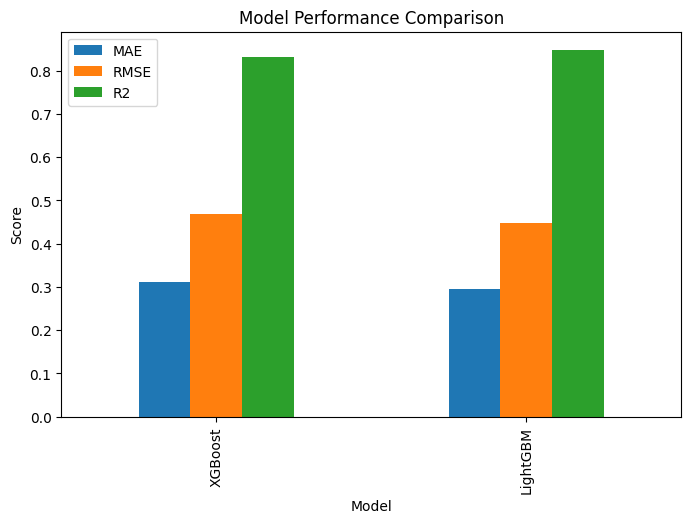

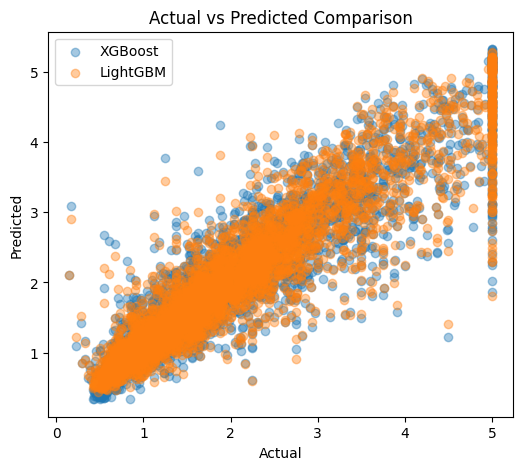

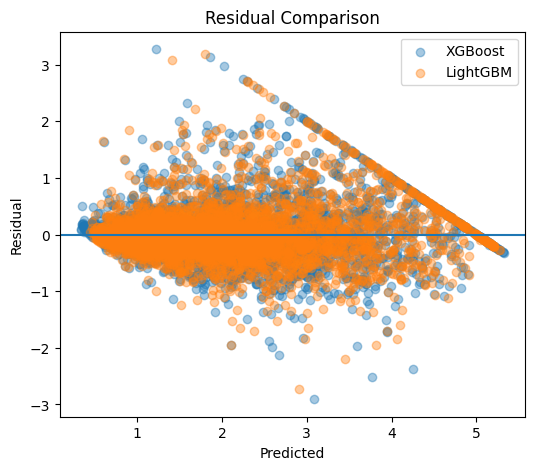

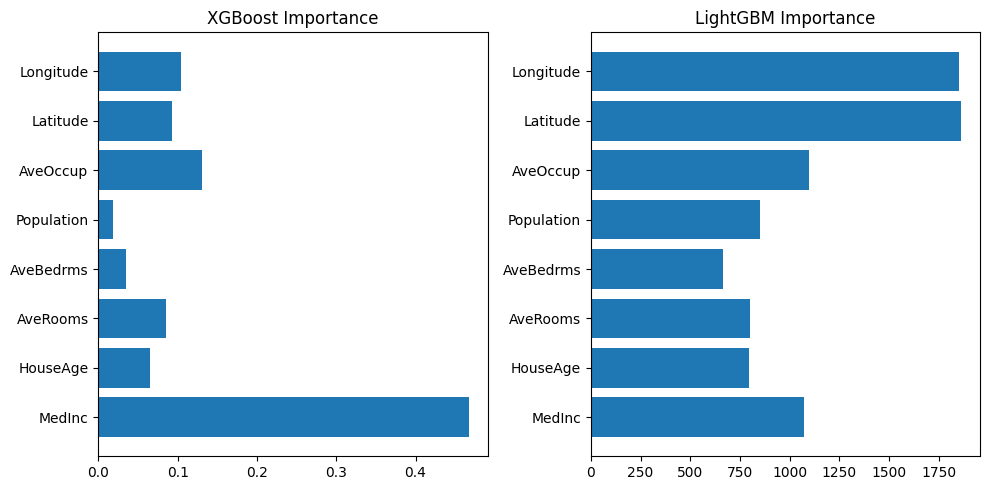

In [1]:
# ============================================================
# [실습] LightGBM vs XGBoost 비교 실습
# ============================================================

# -----------------------------
# 1. 라이브러리 불러오기
# -----------------------------

import numpy as np                # 수치 계산
import pandas as pd               # 데이터 처리
import matplotlib.pyplot as plt   # 시각화

# 데이터셋
from sklearn.datasets import fetch_california_housing

# 데이터 분할
from sklearn.model_selection import train_test_split

# 평가 지표
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 모델
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# -----------------------------
# 2. 데이터 불러오기
# -----------------------------

housing = fetch_california_housing()

X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = pd.Series(housing.target)

# -----------------------------
# 3. 데이터 분할
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# 4. 모델 정의
# -----------------------------

# XGBoost 모델
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# LightGBM 모델
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# -----------------------------
# 5. 모델 학습
# -----------------------------

# XGBoost 학습
xgb_model.fit(X_train, y_train)

# LightGBM 학습
lgb_model.fit(X_train, y_train)

# -----------------------------
# 6. 예측 수행
# -----------------------------

# 각각 모델 예측
xgb_pred = xgb_model.predict(X_test)
lgb_pred = lgb_model.predict(X_test)

# -----------------------------
# 7. 성능 평가 함수 정의
# -----------------------------

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

# 성능 계산
xgb_mae, xgb_rmse, xgb_r2 = evaluate(y_test, xgb_pred)
lgb_mae, lgb_rmse, lgb_r2 = evaluate(y_test, lgb_pred)

# 출력
print("=== XGBoost 성능 ===")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R2   : {xgb_r2:.4f}")

print("\n=== LightGBM 성능 ===")
print(f"MAE  : {lgb_mae:.4f}")
print(f"RMSE : {lgb_rmse:.4f}")
print(f"R2   : {lgb_r2:.4f}")

# -----------------------------
# 8. 성능 비교 시각화
# -----------------------------

# 비교용 데이터프레임 생성
results = pd.DataFrame({
    "Model": ["XGBoost", "LightGBM"],
    "MAE": [xgb_mae, lgb_mae],
    "RMSE": [xgb_rmse, lgb_rmse],
    "R2": [xgb_r2, lgb_r2]
})

# 막대 그래프
results.set_index("Model").plot(kind="bar", figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

# -----------------------------
# 9. 실제값 vs 예측값 비교
# -----------------------------

plt.figure(figsize=(6,5))

# XGBoost
plt.scatter(y_test, xgb_pred, alpha=0.4, label="XGBoost")

# LightGBM
plt.scatter(y_test, lgb_pred, alpha=0.4, label="LightGBM")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Comparison")
plt.legend()
plt.show()

# -----------------------------
# 10. 잔차 비교
# -----------------------------

# 잔차 계산
xgb_residual = y_test - xgb_pred
lgb_residual = y_test - lgb_pred

plt.figure(figsize=(6,5))

# XGBoost
plt.scatter(xgb_pred, xgb_residual, alpha=0.4, label="XGBoost")

# LightGBM
plt.scatter(lgb_pred, lgb_residual, alpha=0.4, label="LightGBM")

plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Comparison")
plt.legend()
plt.show()

# -----------------------------
# 11. Feature Importance 비교
# -----------------------------

# XGBoost 중요도
xgb_importance = xgb_model.feature_importances_

# LightGBM 중요도
lgb_importance = lgb_model.feature_importances_

# 그래프
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.barh(X.columns, xgb_importance)
plt.title("XGBoost Importance")

plt.subplot(1,2,2)
plt.barh(X.columns, lgb_importance)
plt.title("LightGBM Importance")

plt.tight_layout()
plt.show()